# Preclinical Recommendation Demo

This notebook demonstrates the A2H preclinical recommendation pipeline for obesity drug development.

## Content:
1. **Part 1** — Enter your clinical trial design and pair it with all preclinical Liraglutide arms from the A2H database.
2. **Part 2** — Predict translation gaps using the trained model.
3. **Part 3** — Rank and recommend the most translatable preclinical arms.

In [45]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("../../data/obesity")

## Part 1 — Define Your Clinical Trial Design

The cell below contains a **mock example** of a Phase 3 obesity clinical trial.

**Please modify the values to match your own trial design before running the rest of the notebook.**

**Clinical trial parameters:**

| Field | Description | Example values |
|---|---|---|
| `clinical_age_groups` | Target age group(s) | `"ADULT"`, `"OLDER_ADULT"`, `"ADULT,OLDER_ADULT"` |
| `clinical_phases` | Trial phase | `"PHASE1"`, `"PHASE2"`, `"PHASE3"` |
| `clinical_sample_size` | Number of participants in this arm | integer |
| `clinical_dosage_amount_value(mg)` | Dose per administration in mg | float |
| `clinical_dosage_frequency` | Dosing schedule | `"1 + every 1 day"` (once daily), `"2 + every 7 days"` (twice weekly) |
| `clinical_dosage_duration(days)` | Total treatment duration in days | integer |
| `clinical_total_doses` | Total number of administrations | integer |
| `clinical_total_dosage_amount(mg)` | Total cumulative dose in mg | float |
| `clinical_dose_escalation` | Whether dose escalation is used | `"yes"` or `"no"` |
| `clinical_administration_route` | Route of administration | `"subcutaneous"`, `"oral"`, `"intravenous"` |

**Drug pharmacology profile** (used for the PK/PD context plot):

| Field | Description | Example values |
|---|---|---|
| `drug_name` | Name of the drug | string |
| `drug_half_life(hrs)` | Half-life of the drug in hours | float |
| `drug_ec50_ratio` | EC50 relative to native GLP-1 (EC50_drug / EC50_GLP-1) | float |

In [46]:
# ============================================================
# EDIT THIS CELL: Enter your clinical trial design below
# ============================================================

# Mock example: 3.0 mg once-daily subcutaneous (SCALE Obesity, Phase 3)
clinical_trial_design = {
    # --- Patient population ---
    "clinical_age_groups":              "ADULT,OLDER_ADULT",
    "clinical_phases":                  "PHASE3",
    "clinical_sample_size":             396,

    # --- Dosing regimen ---
    "clinical_dosage_amount_value(mg)": 3.0,
    "clinical_dosage_frequency":        "1 + every 1 day",
    "clinical_dosage_duration(days)":   364,
    "clinical_total_doses":             364,
    "clinical_total_dosage_amount(mg)": 1092.0,
    "clinical_dose_escalation":         "yes",
    "clinical_administration_route":    "subcutaneous",

    # --- Outcomes (leave as None — to be predicted) ---
    "clinical_outcome":                 None,
}

# ============================================================

clinical_df = pd.DataFrame([clinical_trial_design])
print("Your clinical trial design:")
clinical_df

Your clinical trial design:


,clinical_age_groups,clinical_phases,clinical_sample_size,clinical_dosage_amount_value(mg),clinical_dosage_frequency,clinical_dosage_duration(days),clinical_total_doses,clinical_total_dosage_amount(mg),clinical_dose_escalation,clinical_administration_route,clinical_outcome
0,"ADULT,OLDER_ADULT",PHASE3,396,3.0,1 + every 1 day,364,364,1092.0,yes,subcutaneous,None


In [47]:
# ============================================================
# EDIT THIS CELL: Enter your drug's pharmacology profile below
# ============================================================

# example:
drug_profile = {
    "drug_name":          "xxxx",
    "drug_half_life(hrs)": 10.5,
    "drug_ec50_ratio":     0.9,   # EC50_drug / EC50_native-GLP-1
}

# ============================================================

print(f"Drug: {drug_profile['drug_name']}  |  "
      f"Half-life: {drug_profile['drug_half_life(hrs)']} hrs  |  "
      f"EC50 ratio: {drug_profile['drug_ec50_ratio']}")

Drug: xxxx  |  Half-life: 10.5 hrs  |  EC50 ratio: 0.9


## Load Preclinical Liraglutide Arms

All preclinical arms with **Liraglutide** are loaded from the A2H PCDB.

In [48]:
preclinical_all = pd.read_csv(DATA_DIR / "preclinical_arms_in_a2h.csv")

preclinical_liraglutide = preclinical_all[
    preclinical_all["intervention"].str.lower() == "liraglutide"
].drop(columns=["preclinical_arm_id"]).reset_index(drop=True)

print(f"Total preclinical arms in A2H:       {len(preclinical_all)}")
print(f"Liraglutide preclinical arms found:  {len(preclinical_liraglutide)}")
preclinical_liraglutide.head()

Total preclinical arms in A2H:       151
Liraglutide preclinical arms found:  45


,pmcid,preclinical_dosage_amount_value(mg/kg),preclinical_dosage_frequency,preclinical_dosage_duration(days),preclinical_administration_route,preclinical_animal_age_before_experiment(days),preclinical_animal_age_before_treatment(days),preclinical_animal_weight_before_experiment(grams),preclinical_animal_weight_before_treatment(grams),preclinical_animal_strain,preclinical_animal_species,preclinical_animal_sex,preclinical_animal_subject_size,preclinical_disease_model,preclinical_outcome,preclinical_total_doses,preclinical_total_dosage_amount(mg/kg),intervention
0,PMC10131131,0.20,2 + every 1 day,14,subcutaneous,77.0,105.0,NaN,NaN,C57BL/6J,mice,male,16.0,diet:high-fat+high-sugar,-14.000000,28.0,5.60,liraglutide
1,PMC10131131,0.20,2 + every 1 day,14,subcutaneous,77.0,105.0,NaN,NaN,C57BL/6J,mice,male,7.0,diet:high-fat,-21.000000,28.0,5.60,liraglutide
2,PMC10131131,0.20,2 + every 1 day,14,subcutaneous,98.0,105.0,NaN,NaN,C57BL/6J,mice,male,10.0,diet:high-fat+high-sugar,-15.000000,28.0,5.60,liraglutide
3,PMC10439806,0.40,1 + every 1 day,28,subcutaneous,56.0,189.0,20.1,55.0,C57BL/6J,mice,male,3.0,diet:high-fat,-32.727273,28.0,11.20,liraglutide
4,PMC10518624,0.07,1 + every 2 days,63,subcutaneous,42.0,168.0,NaN,NaN,C57BL/6J,mice,male,8.0,diet:high-fat+high-fructose,-18.000000,31.0,2.17,liraglutide


## Pair Clinical Trial Design with All Preclinical Arms

Each preclinical Liraglutide arm is paired with the clinical trial design,
producing one row per *(preclinical arm, clinical trial)* pair.

In [ ]:
# Cross-join: every preclinical arm paired with the single clinical trial design
preclinical_liraglutide = preclinical_liraglutide.assign(_key=1)
clinical_df = clinical_df.assign(_key=1)

paired_df = (
    preclinical_liraglutide
    .merge(clinical_df, on="_key")
    .drop(columns=["_key"])
    .reset_index(drop=True)
)


# Reorder columns to match obesity_a2h.csv exactly
OBESITY_A2H_COLUMNS = [
    "pmcid",
    "preclinical_dosage_amount_value(mg/kg)",
    "preclinical_dosage_frequency",
    "preclinical_dosage_duration(days)",
    "preclinical_administration_route",
    "preclinical_animal_age_before_experiment(days)",
    "preclinical_animal_age_before_treatment(days)",
    "preclinical_animal_weight_before_experiment(grams)",
    "preclinical_animal_weight_before_treatment(grams)",
    "preclinical_animal_strain",
    "preclinical_animal_species",
    "preclinical_animal_sex",
    "preclinical_animal_subject_size",
    "preclinical_disease_model",
    "preclinical_total_doses",
    "preclinical_total_dosage_amount(mg/kg)",

    "clinical_age_groups",
    "clinical_phases",
    "clinical_sample_size",
    "clinical_dosage_amount_value(mg)",
    "clinical_dosage_duration(days)",
    "clinical_total_doses",
    "clinical_total_dosage_amount(mg)"
]
paired_df_with_pmcid = paired_df[OBESITY_A2H_COLUMNS].copy()
paired_df = paired_df_with_pmcid.drop(columns=["pmcid"])

print(f"Paired dataframe shape: {paired_df.shape}")
print(f"  → {len(preclinical_liraglutide)} preclinical arms × 1 clinical trial design")
paired_df_with_pmcid.head()

Paired dataframe shape: (45, 23)
  → 45 preclinical arms × 1 clinical trial design


,pmcid,preclinical_dosage_amount_value(mg/kg),preclinical_dosage_frequency,preclinical_dosage_duration(days),preclinical_administration_route,preclinical_animal_age_before_experiment(days),preclinical_animal_age_before_treatment(days),preclinical_animal_weight_before_experiment(grams),preclinical_animal_weight_before_treatment(grams),preclinical_animal_strain,...,preclinical_outcome,preclinical_total_doses,preclinical_total_dosage_amount(mg/kg),clinical_age_groups,clinical_phases,clinical_sample_size,clinical_dosage_amount_value(mg),clinical_dosage_duration(days),clinical_total_doses,clinical_total_dosage_amount(mg)
0,PMC10131131,0.20,2 + every 1 day,14,subcutaneous,77.0,105.0,NaN,NaN,C57BL/6J,...,-14.000000,28.0,5.60,"ADULT,OLDER_ADULT",PHASE3,396,3.0,364,364,1092.0
1,PMC10131131,0.20,2 + every 1 day,14,subcutaneous,77.0,105.0,NaN,NaN,C57BL/6J,...,-21.000000,28.0,5.60,"ADULT,OLDER_ADULT",PHASE3,396,3.0,364,364,1092.0
2,PMC10131131,0.20,2 + every 1 day,14,subcutaneous,98.0,105.0,NaN,NaN,C57BL/6J,...,-15.000000,28.0,5.60,"ADULT,OLDER_ADULT",PHASE3,396,3.0,364,364,1092.0
3,PMC10439806,0.40,1 + every 1 day,28,subcutaneous,56.0,189.0,20.1,55.0,C57BL/6J,...,-32.727273,28.0,11.20,"ADULT,OLDER_ADULT",PHASE3,396,3.0,364,364,1092.0
4,PMC10518624,0.07,1 + every 2 days,63,subcutaneous,42.0,168.0,NaN,NaN,C57BL/6J,...,-18.000000,31.0,2.17,"ADULT,OLDER_ADULT",PHASE3,396,3.0,364,364,1092.0


## Part 2 — Predict Translation Gaps

Each paired row is passed through the trained model to predict translation gaps.

The same preprocessing pipeline (imputation + feature transformation) used during training is
re-fitted on the training set and then applied to the new data before inference.

In [50]:
import sys
import warnings
sys.path.insert(0, str(Path("../..").resolve()))
warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")


from src.obesity_model_performance.ML_pipeline.utils import (
    constants,
    load_best_rgs_pipeline,
    get_simple_pipeline,
)

TRAINING_DRUG = "liraglutide"
RANDOM_STATE  = 42

OUTPUTS_DIR   = Path("../../outputs")
path_data_dir = OUTPUTS_DIR / f"ml_training_{TRAINING_DRUG}/data_processing/splits/rgs_rs-{RANDOM_STATE}"
path_rgs_dir  = OUTPUTS_DIR / f"ml_training_{TRAINING_DRUG}/msap/rgs_rs-{RANDOM_STATE}"

# ── Load training data ─────────────────────────────────────────────────────
data_train = pd.read_csv(path_data_dir / "data_train.csv")
X_train    = data_train.drop(columns=["result_translation"])
y_train    = data_train["result_translation"]

# ── Preprocessing pipeline (fit on training data) ──────────────────────────
prep_pipeline = get_simple_pipeline(X_train, constants.FEATURES_CAT)
prep_pipeline.fit(X_train)

X_train_transformed = prep_pipeline.transform(X_train)
X_new_transformed   = prep_pipeline.transform(paired_df)

# ── Load best model, fit on full training set, then predict ───────────────
model, model_name = load_best_rgs_pipeline(str(path_rgs_dir))
print(f"Model: {model_name}")

model.fit(X_train_transformed, y_train)
print("Model trained on full training set.")
y_pred = model.predict(X_new_transformed)

paired_df["translation_gap_predicted"] = y_pred

print(f"\nFinish translation gap prediction: ({len(y_pred)} arms)")

Model: xg
Model trained on full training set.

Finish translation gap prediction: (45 arms)


In [51]:
paired_df['pmcid'] = paired_df_with_pmcid['pmcid']
paired_df["abs_translation_gap_predicted"] = paired_df["translation_gap_predicted"].abs()
paired_df = paired_df.sort_values(by="abs_translation_gap_predicted", ascending=True).reset_index(drop=True)
paired_df.head()

,preclinical_dosage_amount_value(mg/kg),preclinical_dosage_frequency,preclinical_dosage_duration(days),preclinical_administration_route,preclinical_animal_age_before_experiment(days),preclinical_animal_age_before_treatment(days),preclinical_animal_weight_before_experiment(grams),preclinical_animal_weight_before_treatment(grams),preclinical_animal_strain,preclinical_animal_species,...,clinical_age_groups,clinical_phases,clinical_sample_size,clinical_dosage_amount_value(mg),clinical_dosage_duration(days),clinical_total_doses,clinical_total_dosage_amount(mg),translation_gap_predicted,pmcid,abs_translation_gap_predicted
0,0.011254,2 + every 7 days,28,subcutaneous,35.0,105.0,NaN,35.75,C57BL/6J,mice,...,"ADULT,OLDER_ADULT",PHASE3,396,3.0,364,364,1092.0,0.132994,PMC7755393,0.132994
1,0.200000,1 + every 1 day,21,subcutaneous,NaN,NaN,NaN,514.90,Sprague–Dawley,rats,...,"ADULT,OLDER_ADULT",PHASE3,396,3.0,364,364,1092.0,-0.365676,PMC7211411,0.365676
2,0.200000,1 + every 1 day,21,subcutaneous,NaN,NaN,NaN,514.90,Sprague–Dawley,rats,...,"ADULT,OLDER_ADULT",PHASE3,396,3.0,364,364,1092.0,-0.365676,PMC7211411,0.365676
3,0.040000,1 + every 1 day,70,subcutaneous,5840.0,5840.0,12.0,11500.00,NaN,cynomolgus monkeys,...,"ADULT,OLDER_ADULT",PHASE3,396,3.0,364,364,1092.0,-1.758065,PMC6055720,1.758065
4,0.150000,1 + every 1 day,1,intraperitoneal,28.0,42.0,NaN,33.00,KKAy,mice,...,"ADULT,OLDER_ADULT",PHASE3,396,3.0,364,364,1092.0,-2.259261,PMC3997887,2.259261


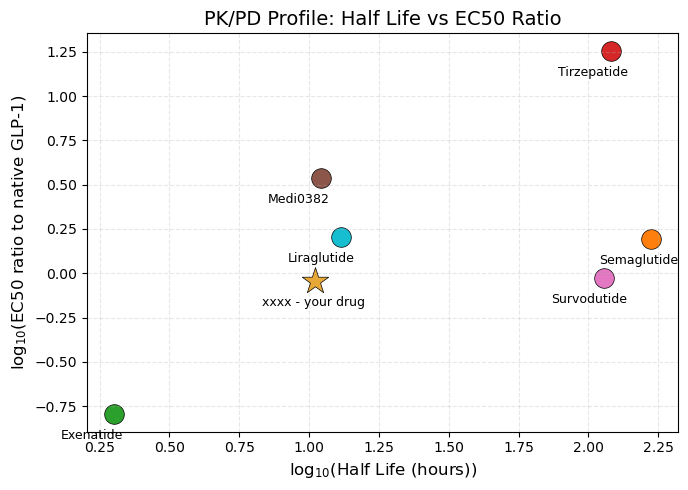

In [52]:
pkpd_df   = pd.read_csv(DATA_DIR / "pkpd_profiles.csv")

color_dict = {
    "Tirzepatide": (0.83921569, 0.15294118, 0.15686275),
    "Semaglutide":  (1.0,        0.49803922, 0.05490196),
    "Survodutide":  (0.89019608, 0.46666667, 0.76078431),
    "Medi0382":     (0.54901961, 0.33725490, 0.29411765),
    "Liraglutide":  (0.09019608, 0.74509804, 0.81176471),
    "Exenatide":    (0.17254902, 0.62745098, 0.17254902),
}
user_color = (0.91, 0.66, 0.22)  # amber — user's drug

fig, ax = plt.subplots(figsize=(7, 5))

# Plot all known drugs from the dataset
for _, row in pkpd_df.iterrows():
    x, y = np.log10(row["half_life(hrs)"]), np.log10(row["EC50_ratio"])
    ax.scatter(x, y,
               c=[color_dict.get(row["Drug"], (0.5, 0.5, 0.5))],
               s=200,
               marker="o",
               edgecolors="black",
               linewidths=0.5)

    ax.annotate(row["Drug"], (x, y),
                textcoords="offset points",
                xytext=(-38, -18),
                fontsize=9)

# Overlay user's drug as a new additional point
x_u = np.log10(drug_profile["drug_half_life(hrs)"])
y_u = np.log10(drug_profile["drug_ec50_ratio"])
ax.scatter(x_u, y_u, c=[user_color], s=400, marker="*",
           edgecolors="black", linewidths=0.5, zorder=3)
ax.annotate(f"{drug_profile['drug_name']} - your drug", (x_u, y_u),
            textcoords="offset points", xytext=(-38, -18), fontsize=9)

ax.set_xlabel("log$_{10}$(Half Life (hours))", fontsize=12)
ax.set_ylabel("log$_{10}$(EC50 ratio to native GLP-1)", fontsize=12)
ax.set_title("PK/PD Profile: Half Life vs EC50 Ratio", fontsize=14)
ax.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

## Predicted Model Performance for Your Drug

The model was trained on Liraglutide data. Its cross-drug performance follows a linear trend
with PK/PD distance to Liraglutide (bootstrap regression, *p* < 0.001).

We use this fitted regression to estimate how well the model is likely to perform when applied
to your drug, based solely on its pharmacological distance to Liraglutide.

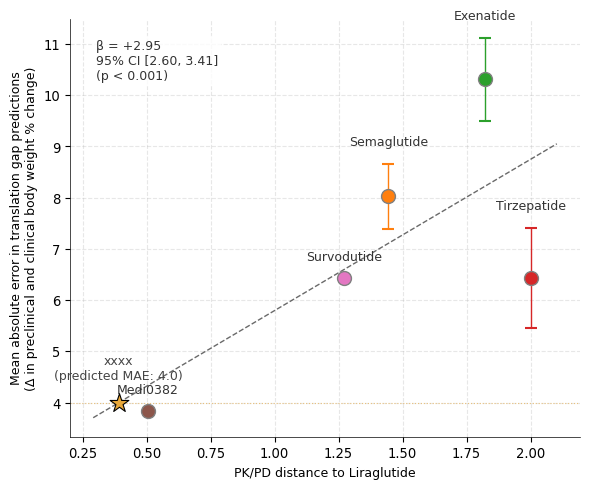


xxxx:
  PK/PD distance to Liraglutide : 0.391
  Predicted MAE (nct)           : 4.00
  → Each predicted translation score is expected to be off by ±4.00 pp on average
    i.e. a score of X should be read as X ± 4.00 percentage points


In [53]:
from scipy import stats

OUTPUTS_CROSS = Path("../../outputs/cross_drug_analysis_liraglutide")
MODEL         = "lira_trained"
DISTANCE_MODE = "both"

# ── Load data ──────────────────────────────────────────────────────────────
nct_table    = pd.read_csv(OUTPUTS_CROSS / "nct_level_metrics.csv")
inference_df = pd.read_csv(OUTPUTS_CROSS / "inference_results_EC50_and_half-life.csv")

# ── Drug-level mean MAE ± 95% CI ───────────────────────────────────────────
nct_sub = nct_table[
    (nct_table["model"] == MODEL) &
    nct_table[f"distance_{DISTANCE_MODE}"].notna()
]
rows = []
for (_, drug), grp in nct_sub.groupby(["model", "test_drug"]):
    vals = grp["MAE_nct"].dropna().values
    dist = grp[f"distance_{DISTANCE_MODE}"].iloc[0]
    if len(vals) == 0 or np.isnan(dist):
        continue
    mean_ = np.mean(vals)
    se    = stats.sem(vals) if len(vals) >= 2 else 0
    rows.append({"test_drug": drug, "distance": dist, "mean": mean_,
                 "ci_low": mean_ - 1.96 * se, "ci_high": mean_ + 1.96 * se})
drug_stats = pd.DataFrame(rows)

# ── Bootstrap regression parameters ───────────────────────────────────────
inf_row       = inference_df[(inference_df["model"] == MODEL) &
                             (inference_df["outcome"] == "MAE_nct")].iloc[0]

beta0         = inf_row["beta0_hat"]
beta1         = inf_row["beta1_hat"]
beta1_ci_low  = inf_row["beta1_boot_CI_low"]
beta1_ci_high = inf_row["beta1_boot_CI_high"]
p_boot        = inf_row["p_boot"]

# ── Compute user drug's PK/PD distance to Liraglutide ─────────────────────
# Z-score using the original 6-drug distribution (same as at model fitting time)
pkpd_ref = pkpd_df.copy()
pkpd_ref["log_ec50"] = np.log(pkpd_ref["EC50_ratio"])
pkpd_ref["log_hl"]   = np.log(pkpd_ref["half_life(hrs)"])
f1_mean, f1_std = pkpd_ref["log_ec50"].mean(), pkpd_ref["log_ec50"].std()
f2_mean, f2_std = pkpd_ref["log_hl"].mean(),   pkpd_ref["log_hl"].std()

lira    = pkpd_ref[pkpd_ref["Drug"] == "Liraglutide"].iloc[0]
z1_lira = (lira["log_ec50"] - f1_mean) / f1_std
z2_lira = (lira["log_hl"]   - f2_mean) / f2_std

z1_user = (np.log(drug_profile["drug_ec50_ratio"])      - f1_mean) / f1_std
z2_user = (np.log(drug_profile["drug_half_life(hrs)"])  - f2_mean) / f2_std

user_dist     = np.sqrt((z1_user - z1_lira)**2 + (z2_user - z2_lira)**2)
user_pred_mae = beta0 + beta1 * user_dist

# ── Plot ───────────────────────────────────────────────────────────────────
DRUG_COLORS = {
    "Liraglutide": "#17BECF", "Semaglutide": "#FF7F0E",
    "Tirzepatide": "#D62728", "Survodutide": "#E377C2",
    "Medi0382":    "#8C564B", "Exenatide":   "#2CA02C",
}

fig, ax = plt.subplots(figsize=(6, 5))

# Existing drugs
for _, row in drug_stats.iterrows():
    ax.errorbar(row["distance"], row["mean"],
                yerr=[[row["mean"] - row["ci_low"]], [row["ci_high"] - row["mean"]]],
                fmt="o",
                color=DRUG_COLORS.get(row["test_drug"], "#333333"),
                markersize=10, markeredgecolor="gray",
                capsize=4, capthick=1.5, elinewidth=1, zorder=3)
    ax.text(row["distance"], row["ci_high"] + 0.3, row["test_drug"],
            ha="center", va="bottom", fontsize=9, color="#333333")

# Regression line (extended to cover user drug's position)
x_vals  = drug_stats["distance"].values
x_range = np.linspace(min(x_vals.min(), user_dist) - 0.1,
                      max(x_vals.max(), user_dist) + 0.1, 100)
ax.plot(x_range, beta0 + beta1 * x_range,
        color="#444444", linestyle="--", linewidth=1, alpha=0.8, zorder=2)

# User's drug — predicted point on the regression line
ax.scatter(user_dist, user_pred_mae,
           color="#E8A83A", s=200, marker="*",
           edgecolors="black", linewidths=0.8, zorder=4)
ax.text(user_dist, user_pred_mae + 0.4,
        f"{drug_profile['drug_name']}\n(predicted MAE: {user_pred_mae:.1f})",
        ha="center", va="bottom", fontsize=9, color="#444444")

# Dotted horizontal reference line to y-axis to read off the predicted MAE value
ax.axhline(user_pred_mae, color="#E8A83A", linestyle=":", linewidth=0.8, alpha=0.6)

# Regression stats
sign  = "+" if beta1 >= 0 else ""
p_str = "(p < 0.001)" if p_boot < 0.001 else f"(p = {p_boot:.3f})"
ax.text(0.05, 0.95,
        f"β = {sign}{beta1:.2f}\n95% CI [{beta1_ci_low:.2f}, {beta1_ci_high:.2f}]\n{p_str}",
        transform=ax.transAxes, ha="left", va="top", fontsize=9, color="#333333",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.8))

ax.set_xlabel("PK/PD distance to Liraglutide", fontsize=9, fontweight="medium")
ax.set_ylabel("Mean absolute error in translation gap predictions\n"
              "(Δ in preclinical and clinical body weight % change)",
              fontsize=9, fontweight="medium")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)
ax.tick_params(axis="both", labelsize=9.5)
ax.grid(True, linestyle="--", alpha=0.3, zorder=0)
plt.tight_layout()
plt.show()

print(f"\n{drug_profile['drug_name']}:")
print(f"  PK/PD distance to Liraglutide : {user_dist:.3f}")
print(f"  Predicted MAE (nct)           : {user_pred_mae:.2f}")
print(f"  → Each predicted translation score is expected to be off by ±{user_pred_mae:.2f} pp on average")
print(f"    i.e. a score of X should be read as X ± {user_pred_mae:.2f} percentage points")

## Part 3 — Recommendation

The arm with the smallest predicted `|translation_gap|` is selected. The expected model error (±MAE) derived from the regression above is included to give an honest range for the actual translation gap.

In [ ]:
from IPython.display import Markdown, display

# Best arm = smallest |translation_gap_predicted| (closest to 0 = best translation)
best_idx = paired_df["translation_gap_predicted"].abs().argmin()
best = paired_df.iloc[best_idx]

def _fmt(val, fmt=None, fallback="N/A"):
    if pd.isna(val):
        return fallback
    return fmt.format(val) if fmt else str(val)

score      = best["translation_gap_predicted"]
score_low  = score - user_pred_mae
score_high = score + user_pred_mae

recommendation = f"""\
## Recommended Preclinical Study Design

Based on predicted translational gaps across **{len(paired_df)}** preclinical Liraglutide \
arms, the design with the closest alignment to your **{best['clinical_phases']}** trial \
({_fmt(best['clinical_sample_size'], '{:.0f}')} participants, \
{_fmt(best['clinical_dosage_amount_value(mg)'])} mg/dose, \
{_fmt(best['clinical_dosage_duration(days)'], '{:.0f}')} days of treatment) is preclinical arm \
**(PMCID: {best['pmcid']})**. Its predicted translation gap is **{score:.2f}%** body weight \
change difference between the preclinical and clinical endpoints. Based on empirical cross-drug \
performance, the expected model error is **±{user_pred_mae:.1f} percentage points**, placing \
the likely actual range at **[{score_low:.1f}, {score_high:.1f}]%**.

The recommended animal model is **{_fmt(best['preclinical_animal_species'])}** \
({_fmt(best['preclinical_animal_strain'])}, {_fmt(best['preclinical_animal_sex'])}) \
on a **{_fmt(best['preclinical_disease_model'])}** disease background, \
with approximately {_fmt(best['preclinical_animal_subject_size'], '{:.0f}')} animals per group. \
Treatment should begin at approximately \
{_fmt(best['preclinical_animal_age_before_treatment(days)'], '{:.0f}')} days of age \
(pre-treatment body weight ~{_fmt(best['preclinical_animal_weight_before_treatment(grams)'], '{:.1f}')} g).

Your tested drug should be administered at **{_fmt(best['preclinical_dosage_amount_value(mg/kg)'])} mg/kg** \
via **{_fmt(best['preclinical_administration_route'])}** injection, dosed \
**{_fmt(best['preclinical_dosage_frequency'])}** over \
**{_fmt(best['preclinical_dosage_duration(days)'], '{:.0f}')} days** \
({_fmt(best['preclinical_total_doses'], '{:.0f}')} total administrations; \
cumulative dose: {_fmt(best['preclinical_total_dosage_amount(mg/kg)'], '{:.1f}')} mg/kg).\
"""

display(Markdown(recommendation))

## Recommended Preclinical Study Design

Based on predicted translational outcomes across **45** preclinical Liraglutide arms, the design with the closest alignment to your **PHASE3** trial (396 participants, 3.0 mg/dose, 364 days of treatment) is preclinical arm **(PMCID: PMC7755393)**. Its predicted translation gap is **0.13%** body weight change difference between the preclinical and clinical endpoints. Based on empirical cross-drug performance, the expected model error is **±4.0 percentage points**, placing the likely actual range at **[-3.9, 4.1]%**.

The recommended animal model is **mice** (C57BL/6J, male) on a **diet:high-fat+high-sugar** disease background, with approximately 4 animals per group. Treatment should begin at approximately 105 days of age (pre-treatment body weight ~35.8 g).

Your tested drug should be administered at **0.01125378 mg/kg** via **subcutaneous** injection, dosed **2 + every 7 days** over **28 days** (8 total administrations; cumulative dose: 0.1 mg/kg).